<a href="https://colab.research.google.com/github/spesivan/colab-notes-v2/blob/main/keras_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# https://keras.io/examples/vision/image_classification_from_scratch/

In [32]:
import os
import numpy as np
import keras
import tensorflow as tf
from keras import layers
from tensorflow import data as tf_data
import matplotlib.pyplot as plt

In [17]:
!curl -O https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  786M  100  786M    0     0  87.5M      0  0:00:08  0:00:08 --:--:-- 63.8M


In [18]:
!unzip -q kagglecatsanddogs_5340.zip
!ls

replace PetImages/Cat/0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename:  CDLA-Permissive-2.0.pdf      save_at_12.keras	 save_at_1.keras    save_at_3.keras
 kagglecatsanddogs_5340.zip   save_at_13.keras	 save_at_20.keras   save_at_4.keras
 model.png		      save_at_14.keras	 save_at_21.keras   save_at_5.keras
 PetImages		      save_at_15.keras	 save_at_22.keras   save_at_6.keras
'readme[1].txt'		      save_at_16.keras	 save_at_23.keras   save_at_7.keras
 sample_data		      save_at_17.keras	 save_at_24.keras   save_at_8.keras
 save_at_10.keras	      save_at_18.keras	 save_at_25.keras   save_at_9.keras
 save_at_11.keras	      save_at_19.keras	 save_at_2.keras


In [19]:
!ls PetImages

Cat  Dog


In [20]:
num_skipped = 0
for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join("PetImages", folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = b"JFIF" in fobj.peek(10)
        finally:
            fobj.close()

        if not is_jfif:
            num_skipped += 1
            # Delete corrupted image
            os.remove(fpath)

print(f"Deleted {num_skipped} images.")

Deleted 0 images.


In [21]:
image_size = (180, 180)
batch_size = 128

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    "PetImages",
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

Found 23410 files belonging to 2 classes.
Using 18728 files for training.
Using 4682 files for validation.


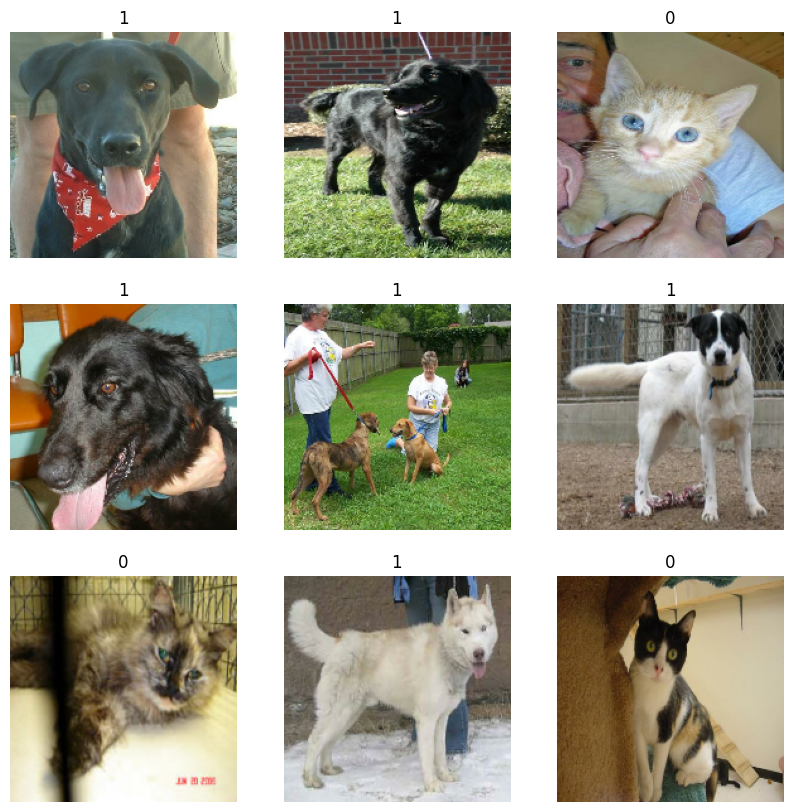

In [22]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

In [23]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]


def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

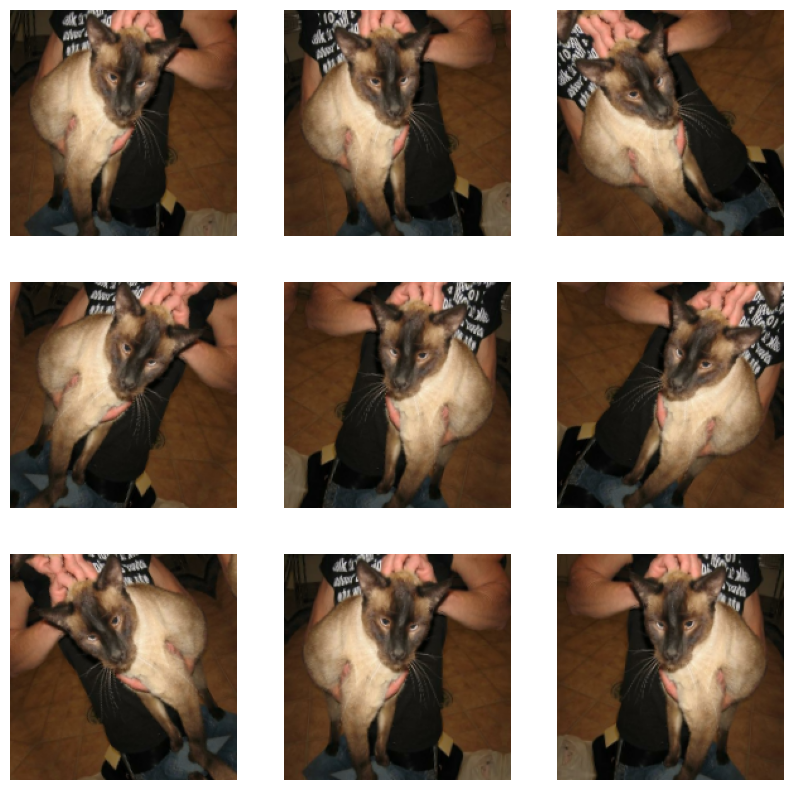

In [24]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")

In [25]:
# Apply `data_augmentation` to the training images.
train_ds = train_ds.map(
    lambda img, label: (data_augmentation(img), label),
    num_parallel_calls=tf_data.AUTOTUNE,
)
# Prefetching samples in GPU memory helps maximize GPU utilization.
train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)

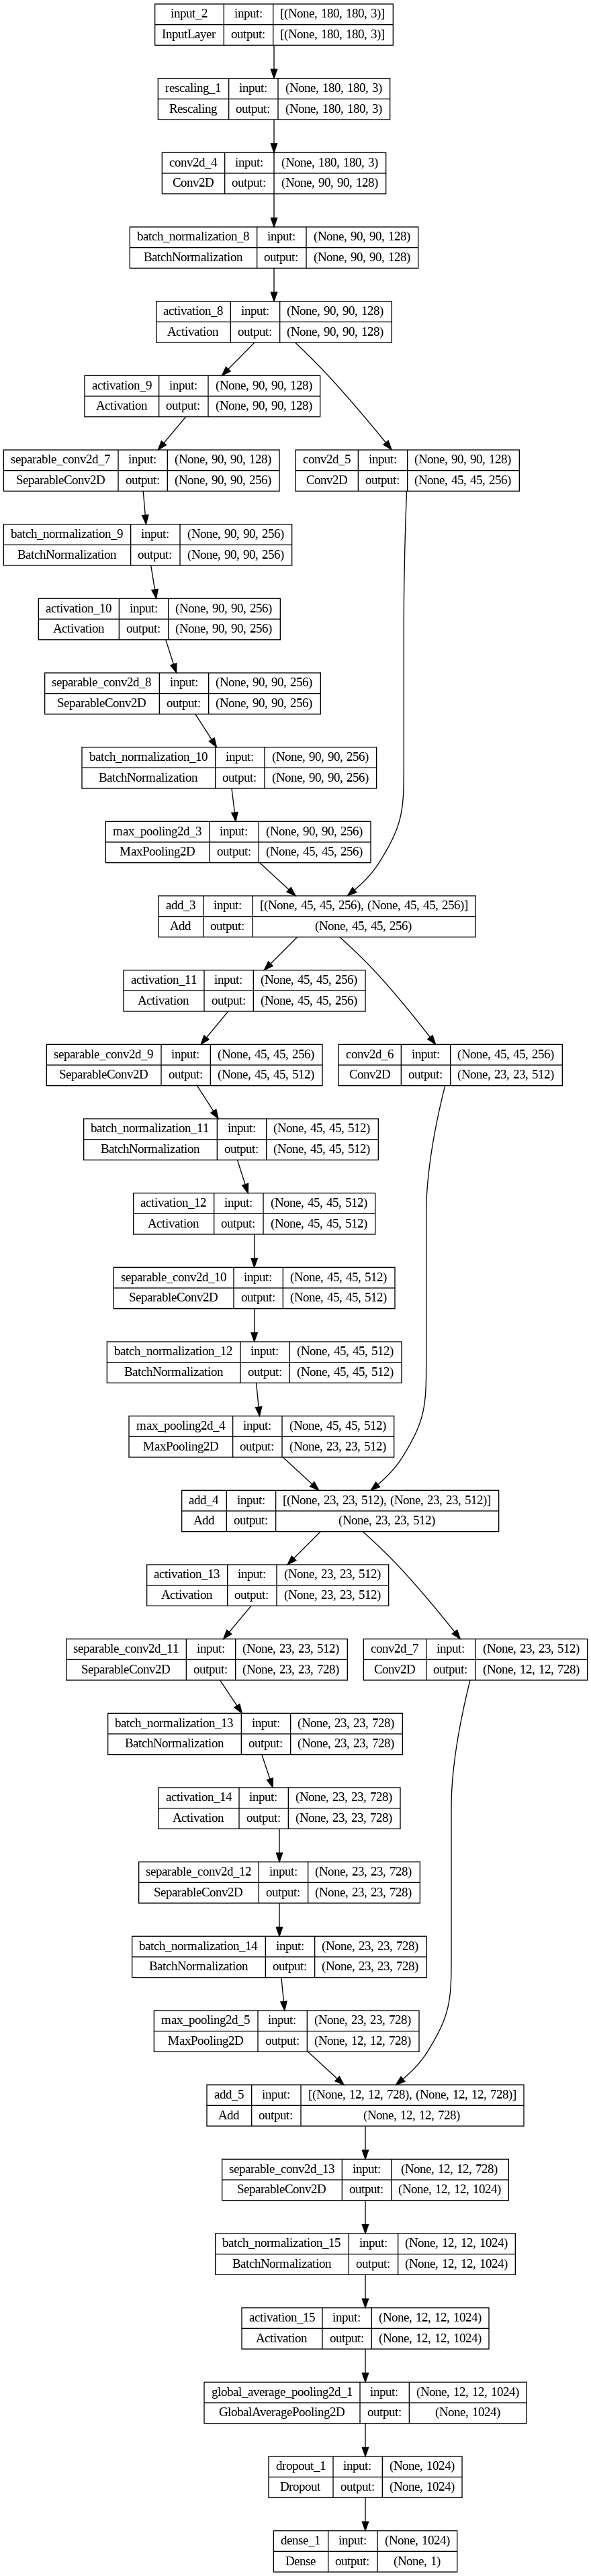

In [26]:
def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    # Entry block
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x  # Set aside residual

    for size in [256, 512, 728]:
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

        # Project residual
        residual = layers.Conv2D(size, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    x = layers.SeparableConv2D(1024, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    if num_classes == 2:
        units = 1
    else:
        units = num_classes

    x = layers.Dropout(0.25)(x)
    # We specify activation=None so as to return logits
    outputs = layers.Dense(units, activation=None)(x)
    return keras.Model(inputs, outputs)


model = make_model(input_shape=image_size + (3,), num_classes=2)
keras.utils.plot_model(model, show_shapes=True)

In [13]:
epochs = 25

callbacks = [
    keras.callbacks.ModelCheckpoint("save_at_{epoch}.keras"),
]
model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[keras.metrics.BinaryAccuracy(name="acc")],
)
model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds,
)

Epoch 1/25
147/147 [==============================] - 253s 1s/step - loss: 0.5891 - acc: 0.6693 - val_loss: 0.7021 - val_acc: 0.4957
Epoch 2/25
147/147 [==============================] - 214s 1s/step - loss: 0.4592 - acc: 0.7708 - val_loss: 0.6987 - val_acc: 0.4957
Epoch 3/25
147/147 [==============================] - 222s 1s/step - loss: 0.3690 - acc: 0.8259 - val_loss: 0.6918 - val_acc: 0.4957
Epoch 4/25
147/147 [==============================] - 215s 1s/step - loss: 0.3096 - acc: 0.8624 - val_loss: 0.7284 - val_acc: 0.4966
Epoch 5/25
147/147 [==============================] - 217s 1s/step - loss: 0.2703 - acc: 0.8812 - val_loss: 0.5115 - val_acc: 0.6585
Epoch 6/25
147/147 [==============================] - 222s 2s/step - loss: 0.2426 - acc: 0.8938 - val_loss: 0.6154 - val_acc: 0.8138
Epoch 7/25
147/147 [==============================] - 216s 1s/step - loss: 0.2140 - acc: 0.9068 - val_loss: 0.3608 - val_acc: 0.8276
Epoch 8/25
147/147 [==============================] - 216s 1s/step - 

1/1 [==============================] - 1s 837ms/step
This image is 50.06% cat and 49.94% dog.


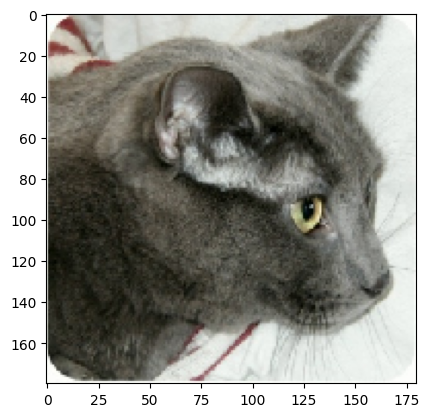

In [33]:
img = keras.utils.load_img("PetImages/Cat/6779.jpg", target_size=image_size)
plt.imshow(img)

img_array = keras.utils.img_to_array(img)
img_array = tf.keras.backend.expand_dims(img_array, 0)  # Create batch axis

predictions = model.predict(img_array)
score = float(tf.keras.backend.sigmoid(predictions[0][0]))
print(f"This image is {100 * (1 - score):.2f}% cat and {100 * score:.2f}% dog.")

1/1 [==============================] - 0s 22ms/step
This image is 50.07% cat and 49.93% dog.


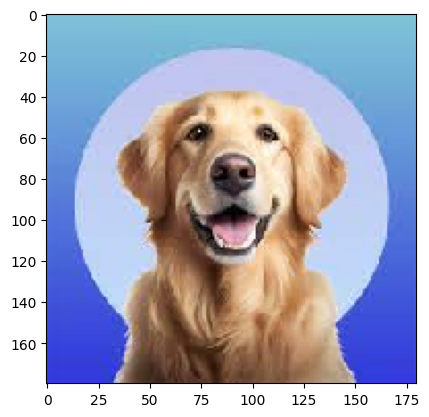

In [34]:
img = keras.utils.load_img("köpek.jpg", target_size=image_size)
plt.imshow(img)

img_array = keras.utils.img_to_array(img)
img_array = tf.keras.backend.expand_dims(img_array, 0)  # Create batch axis

predictions = model.predict(img_array)
score = float(tf.keras.backend.sigmoid(predictions[0][0]))
print(f"This image is {100 * (1 - score):.2f}% cat and {100 * score:.2f}% dog.")